# Dynamic Pricing Optimization - Phase 2: Feature Engineering

This notebook focuses on turning the processed Phase 1 dataset into a model-ready feature matrix.

## Phase 2 Goals
1. Load Phase 1 processed dataset
2. Add cyclical time features
3. Create interaction features
4. Encode categorical features
5. Scale numerical features
6. Run feature relevance checks
7. Export engineered and ML-ready datasets

In [23]:
import os
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import f_regression

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Make src importable from notebook location
sys.path.append(os.path.abspath('../src'))

from feature_engineering import (
    load_processed_data,
    add_cyclical_time_features,
    add_interaction_features,
    encode_categorical_features,
    drop_low_information_features,
    get_feature_target_split,
    scale_numerical_features,
    build_phase2_dataset
)

print('Phase 2 imports loaded successfully.')

Phase 2 imports loaded successfully.


## 1. Load Input Data

In [21]:
df = load_processed_data('../data/walmart_model_ready.csv')
print(f'Input shape: {df.shape}')
df.head()

Input shape: (6255, 22)


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,...,Quarter,Holiday_Type,Season,Sales_Lag_1,Sales_Lag_2,Sales_Rolling_Mean_4,Sales_Rolling_Std_4,Base_Price,Season_Price_Factor,Price
0,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,...,1,Non-Holiday,Spring,1409727.59,1611968.17,1.510848e+06,143005.685549,80.0,1.0,80.73
1,1,2010-03-12,1439541.59,0,57.79,2.667,211.380643,8.106,2010,3,...,1,Non-Holiday,Spring,1554806.68,1409727.59,1.525501e+06,104256.598906,80.0,1.0,84.31
2,1,2010-03-19,1472515.79,0,54.58,2.720,211.215635,8.106,2010,3,...,1,Non-Holiday,Spring,1439541.59,1554806.68,1.504011e+06,95360.050839,80.0,1.0,77.61
3,1,2010-03-26,1404429.92,0,51.45,2.732,211.018042,8.106,2010,3,...,1,Non-Holiday,Spring,1472515.79,1439541.59,1.469148e+06,62599.457150,80.0,1.0,77.65
4,1,2010-04-02,1594968.28,0,62.27,2.719,210.820450,7.808,2010,4,...,2,Non-Holiday,Spring,1404429.92,1472515.79,1.467823e+06,64308.381016,80.0,1.0,84.72


In [22]:
print('Columns available for Phase 2:')
for i, c in enumerate(df.columns, 1):
    print(f'{i:2}. {c}')

Columns available for Phase 2:
 1. Store
 2. Date
 3. Weekly_Sales
 4. Holiday_Flag
 5. Temperature
 6. Fuel_Price
 7. CPI
 8. Unemployment
 9. Year
10. Month
11. Week
12. Day_of_Week
13. Quarter
14. Holiday_Type
15. Season
16. Sales_Lag_1
17. Sales_Lag_2
18. Sales_Rolling_Mean_4
19. Sales_Rolling_Std_4
20. Base_Price
21. Season_Price_Factor
22. Price


## 2. Add New Features

In [3]:
df_cycle = add_cyclical_time_features(df)
new_cycle_cols = [c for c in df_cycle.columns if c not in df.columns]
print('Cyclical features added:')
print(new_cycle_cols)
df_cycle[new_cycle_cols].head()

Cyclical features added:
['Month_sin', 'Month_cos', 'Week_sin', 'Week_cos', 'Quarter_sin', 'Quarter_cos']


,Month_sin,Month_cos,Week_sin,Week_cos,Quarter_sin,Quarter_cos
0,1.000000,6.123234e-17,0.885456,4.647232e-01,1.000000e+00,6.123234e-17
1,1.000000,6.123234e-17,0.935016,3.546049e-01,1.000000e+00,6.123234e-17
2,1.000000,6.123234e-17,0.970942,2.393157e-01,1.000000e+00,6.123234e-17
3,1.000000,6.123234e-17,0.992709,1.205367e-01,1.000000e+00,6.123234e-17
4,0.866025,-5.000000e-01,1.000000,-1.608123e-16,1.224647e-16,-1.000000e+00


In [4]:
df_inter = add_interaction_features(df_cycle)
new_inter_cols = [c for c in df_inter.columns if c not in df_cycle.columns]
print('Interaction features added:')
print(new_inter_cols)
df_inter[new_inter_cols].describe().T

Interaction features added:
['Price_Holiday_Interaction', 'Price_Unemployment_Interaction', 'Temperature_Fuel_Interaction', 'CPI_Unemployment_Interaction']


,count,mean,std,min,25%,50%,75%,max
Price_Holiday_Interaction,6255.0,5.989699,22.850610,0.000000,0.000000,0.000000,0.000000,114.740000
Price_Unemployment_Interaction,6255.0,720.297364,189.759344,288.851400,597.481570,701.557500,802.181875,1572.283050
Temperature_Fuel_Interaction,6255.0,208.063902,69.707102,-6.202660,155.983570,208.979700,263.870565,387.353580
CPI_Unemployment_Interaction,6255.0,1348.159885,337.550362,508.442511,1100.773155,1375.278306,1623.458427,2218.390076


## 3. Categorical Encoding

In [12]:
df_encoded = encode_categorical_features(df_inter, drop_first=False)
df_encoded, dropped_cols = drop_low_information_features(df_encoded)

encoded_cols = [c for c in df_encoded.columns if c not in df_inter.columns]
print(f'One-hot encoded columns created: {len(encoded_cols)}')
print(encoded_cols[:12])
print(f'Dropped low-information columns: {dropped_cols}')

One-hot encoded columns created: 6
['Season_Fall', 'Season_Spring', 'Season_Summer', 'Season_Winter', 'Holiday_Type_Holiday', 'Holiday_Type_Non-Holiday']
Dropped low-information columns: ['Day_of_Week', 'Base_Price']


## 4. Feature Matrix and Scaling

In [13]:
X, y = get_feature_target_split(df_encoded, target_col='Weekly_Sales')
print(f'Feature matrix shape: {X.shape}')
print(f'Target shape: {y.shape}')

Feature matrix shape: (6255, 32)
Target shape: (6255,)


In [14]:
X_scaled, scaler, scaled_cols = scale_numerical_features(X)
print(f'Scaled numerical columns: {len(scaled_cols)}')
print(scaled_cols[:15])

Scaled numerical columns: 32
['Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Year', 'Month', 'Week', 'Quarter', 'Sales_Lag_1', 'Sales_Lag_2', 'Sales_Rolling_Mean_4', 'Sales_Rolling_Std_4', 'Season_Price_Factor']


In [9]:
print('Post-scaling check for first 5 numeric columns (mean approx 0, std approx 1):')
check_cols = scaled_cols[:5]
for col in check_cols:
    print(f"{col}: mean={X_scaled[col].mean():.4f}, std={X_scaled[col].std():.4f}")

Post-scaling check for first 5 numeric columns (mean approx 0, std approx 1):
Store: mean=0.0000, std=1.0001
Holiday_Flag: mean=0.0000, std=1.0001
Temperature: mean=-0.0000, std=1.0001
Fuel_Price: mean=0.0000, std=1.0001
CPI: mean=-0.0000, std=1.0001


## 5. Feature Relevance Snapshot

In [18]:
# Use univariate F-test as a quick relevance check
f_scores, p_values = f_regression(X_scaled.select_dtypes(include=[np.number]), y)
score_df = pd.DataFrame({
    'Feature': X_scaled.select_dtypes(include=[np.number]).columns,
    'F_Score': f_scores,
    'P_Value': p_values
}).sort_values('F_Score', ascending=False)

score_df.head(15)

,Feature,F_Score,P_Value
12,Sales_Rolling_Mean_4,73232.019114,0.000000e+00
10,Sales_Lag_1,58992.794142,0.000000e+00
11,Sales_Lag_2,47664.695759,0.000000e+00
13,Sales_Rolling_Std_4,1008.447717,2.591345e-205
0,Store,786.862123,3.469825e-163
15,Price,396.052343,1.688110e-85
23,Price_Unemployment_Interaction,216.693583,3.033630e-48
25,CPI_Unemployment_Interaction,115.697115,9.481010e-27
5,Unemployment,76.086365,3.436630e-18
7,Month,40.481066,2.125915e-10


D:\Temp\ipykernel_14020\2053916124.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_features, x='F_Score', y='Feature', palette='viridis')


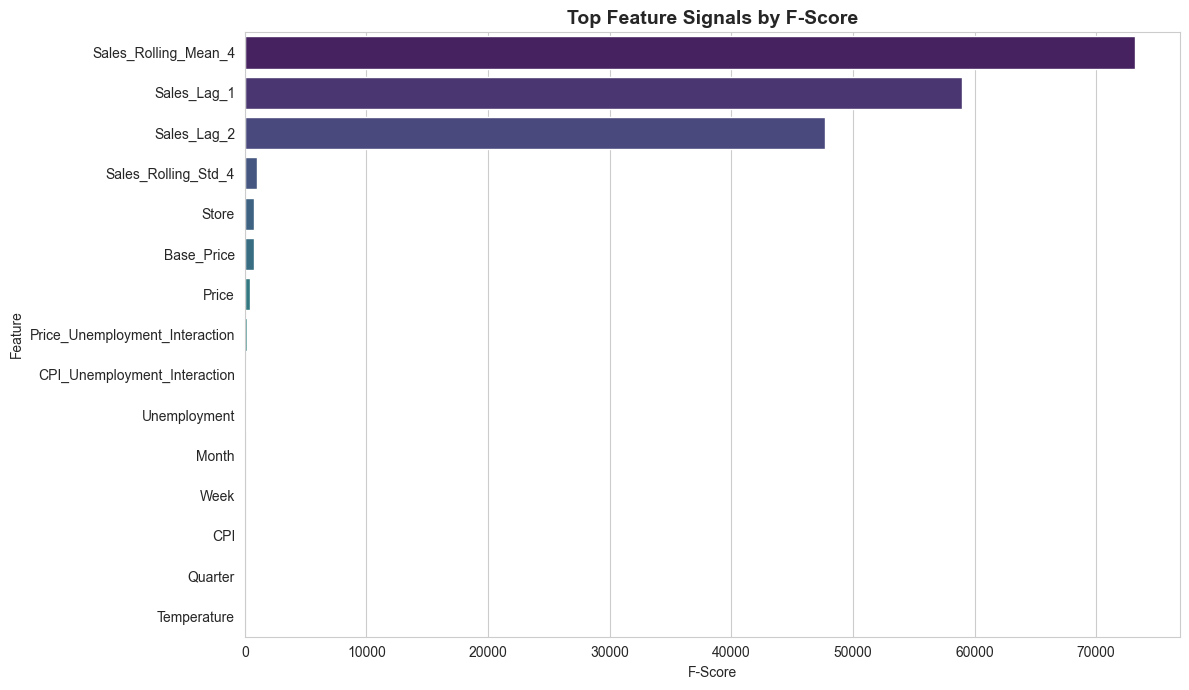

Saved: ../output/phase2_top_feature_scores.png


In [15]:
top_k = 15
top_features = score_df.head(top_k)

plt.figure(figsize=(12, 7))
sns.barplot(data=top_features, x='F_Score', y='Feature', palette='viridis')
plt.title('Top Feature Signals by F-Score', fontsize=14, fontweight='bold')
plt.xlabel('F-Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('../output/phase2_top_feature_scores.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: ../output/phase2_top_feature_scores.png')

## 6. Correlation Heatmap for Selected Features

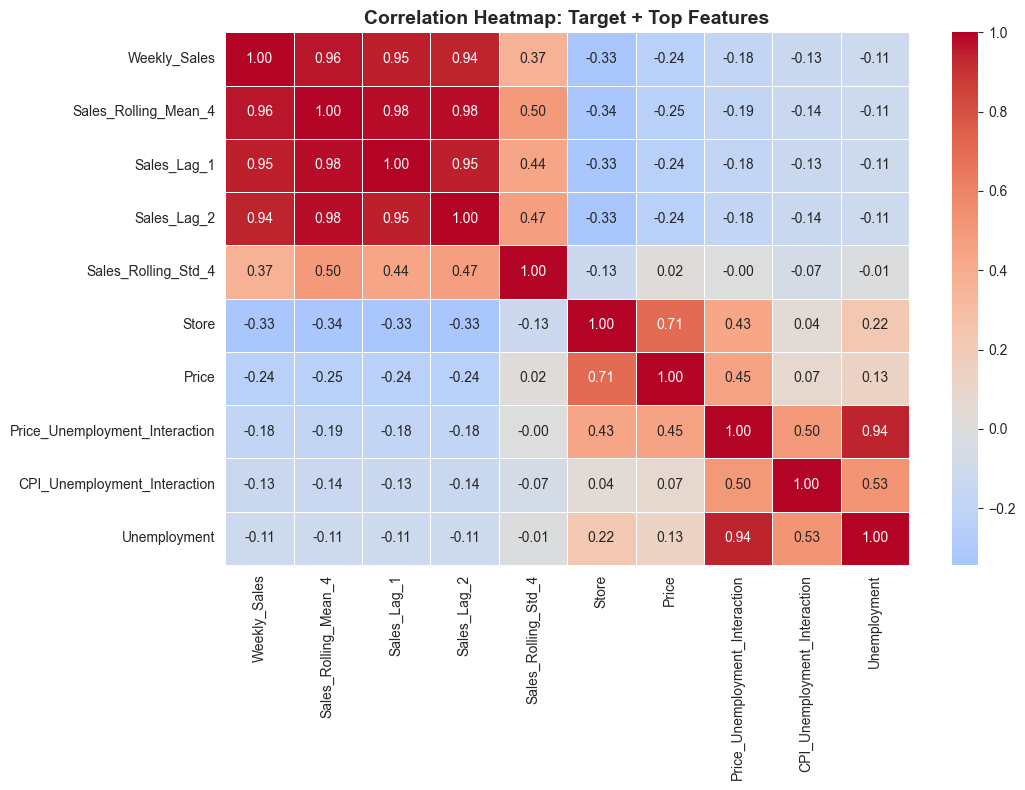

Saved: ../output/phase2_correlation_heatmap.png


In [19]:
selected_candidates = ['Weekly_Sales'] + top_features['Feature'].head(10).tolist()
corr_df = X_scaled.copy()
corr_df['Weekly_Sales'] = y.values

# Keep only columns currently present after feature cleanup.
selected = [col for col in selected_candidates if col in corr_df.columns]
corr_matrix = corr_df[selected].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=True, fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap: Target + Top Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../output/phase2_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: ../output/phase2_correlation_heatmap.png')

## 7. Save Phase 2 Outputs

In [17]:
# Save leakage-safe Phase 2 outputs
# Keep data unscaled here; scaling must be fit on train split during Phase 3.
df_feature_engineered = build_phase2_dataset(df)
df_feature_engineered.to_csv('../data/walmart_feature_engineered.csv', index=False)

# ML-ready here means feature-complete and encoded for modeling workflow
# (actual train/test split and scaling happens in Phase 3).
df_ml_ready = df_feature_engineered.copy()
df_ml_ready.to_csv('../data/walmart_ml_ready.csv', index=False)

print('Saved: ../data/walmart_feature_engineered.csv')
print('Saved: ../data/walmart_ml_ready.csv')
print(f'Feature engineered shape: {df_feature_engineered.shape}')
print(f'ML ready shape: {df_ml_ready.shape}')

Saved: ../data/walmart_feature_engineered.csv
Saved: ../data/walmart_ml_ready.csv
Feature engineered shape: (6255, 34)
ML ready shape: (6255, 34)


## Phase 2 Summary

In this phase, we created model-ready features by:
- adding cyclical time encodings
- creating interaction terms
- encoding categorical variables
- scaling numerical features
- exporting clean datasets for Phase 3 modeling

Next: Phase 3 demand prediction models (Linear Regression, Random Forest, Gradient Boosting).

In [2]:
import sys
print(sys.executable)

d:\GitHub\Dynamic-Pricing-Optimization-Using-Demand-Elasticity\d_env\Scripts\python.exe


In [14]:
# Correlation matrix sanity checks
import numpy as np

# Recompute from current scaled feature set and target
corr_df_check = X_scaled.copy()
corr_df_check['Weekly_Sales'] = y.values
corr_check = corr_df_check.corr(numeric_only=True)

max_symmetry_diff = (corr_check - corr_check.T).abs().to_numpy().max()
diag_all_one = np.allclose(np.diag(corr_check), 1.0, atol=1e-10)
in_bounds = ((corr_check.values >= -1) & (corr_check.values <= 1)).all()

print(f"Correlation matrix shape: {corr_check.shape}")
print(f"Max |corr - corr.T|: {max_symmetry_diff:.12f}")
print(f"Diagonal all ones: {diag_all_one}")
print(f"All values in [-1, 1]: {in_bounds}")

# Same check on selected matrix used for plot
selected_check = ['Weekly_Sales'] + top_features['Feature'].head(10).tolist()
corr_selected = corr_df_check[selected_check].corr(numeric_only=True)

print("\nSelected heatmap matrix checks:")
print(f"Shape: {corr_selected.shape}")
print(f"Max |corr - corr.T|: {(corr_selected - corr_selected.T).abs().to_numpy().max():.12f}")
print(f"Diagonal all ones: {np.allclose(np.diag(corr_selected), 1.0, atol=1e-10)}")
print(f"All values in [-1, 1]: {((corr_selected.values >= -1) & (corr_selected.values <= 1)).all()}")

# Show the strongest absolute correlations with target
target_corr = corr_selected['Weekly_Sales'].drop('Weekly_Sales').abs().sort_values(ascending=False)
print("\nTop absolute correlations with Weekly_Sales (selected):")
print(target_corr.head(5))

Correlation matrix shape: (35, 35)
Max |corr - corr.T|: nan
Diagonal all ones: False
All values in [-1, 1]: False

Selected heatmap matrix checks:
Shape: (11, 11)
Max |corr - corr.T|: 0.000000000000
Diagonal all ones: True
All values in [-1, 1]: True

Top absolute correlations with Weekly_Sales (selected):
Sales_Rolling_Mean_4    0.959860
Sales_Lag_1             0.950875
Sales_Lag_2             0.940227
Sales_Rolling_Std_4     0.372662
Store                   0.334324
Name: Weekly_Sales, dtype: float64


In [15]:
# Diagnose NaNs in full correlation matrix
std_series = corr_df_check.std(numeric_only=True)
zero_var_cols = std_series[std_series == 0].index.tolist()

nan_corr_cols = corr_check.columns[corr_check.isna().any()].tolist()

print(f"Zero-variance columns: {len(zero_var_cols)}")
print(zero_var_cols)
print(f"\nColumns with NaN correlations: {len(nan_corr_cols)}")
print(nan_corr_cols)

Zero-variance columns: 1
['Day_of_Week']

Columns with NaN correlations: 35
['Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Year', 'Month', 'Week', 'Day_of_Week', 'Quarter', 'Sales_Lag_1', 'Sales_Lag_2', 'Sales_Rolling_Mean_4', 'Sales_Rolling_Std_4', 'Base_Price', 'Season_Price_Factor', 'Price', 'Month_sin', 'Month_cos', 'Week_sin', 'Week_cos', 'Quarter_sin', 'Quarter_cos', 'Price_Holiday_Interaction', 'Price_Unemployment_Interaction', 'Temperature_Fuel_Interaction', 'CPI_Unemployment_Interaction', 'Season_Fall', 'Season_Spring', 'Season_Summer', 'Season_Winter', 'Holiday_Type_Holiday', 'Holiday_Type_Non-Holiday', 'Weekly_Sales']
